In [1]:
import xarray as xr
import numpy as np
import geopandas as gpd
import regionmask

### Load ERA5-Land data

In [2]:
era5land = xr.open_dataset('era5_land_aug_2019.nc') # open ERA5-Land NetCDF file
print(era5land) # view structure

<xarray.Dataset> Size: 180MB
Dimensions:     (valid_time: 744, latitude: 96, longitude: 105)
Coordinates:
  * valid_time  (valid_time) datetime64[ns] 6kB 2019-08-01 ... 2019-08-31T23:...
  * latitude    (latitude) float64 768B 42.0 41.9 41.8 41.7 ... 32.7 32.6 32.5
  * longitude   (longitude) float64 840B -124.5 -124.4 -124.3 ... -114.2 -114.1
    number      int64 8B ...
    expver      (valid_time) <U4 12kB ...
Data variables:
    d2m         (valid_time, latitude, longitude) float32 30MB ...
    t2m         (valid_time, latitude, longitude) float32 30MB ...
    ssrd        (valid_time, latitude, longitude) float32 30MB ...
    u10         (valid_time, latitude, longitude) float32 30MB ...
    v10         (valid_time, latitude, longitude) float32 30MB ...
    sp          (valid_time, latitude, longitude) float32 30MB ...
Attributes:
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conv

### Load NN-interpolated ERA5 data

In [3]:
era5_nn_2019 = xr.open_dataset('era5_nn_2019.nc') # ERA5 after NN interpolating
print(era5_nn_2019) # view structure
print(abs(era5_nn_2019["ssrd"].latitude[1] - era5_nn_2019["ssrd"].latitude[0]).values)  # view resolution of ERA5 fdir: 0.1

<xarray.Dataset> Size: 60MB
Dimensions:     (valid_time: 744, latitude: 96, longitude: 105)
Coordinates:
  * valid_time  (valid_time) datetime64[ns] 6kB 2019-08-01 ... 2019-08-31T23:...
  * latitude    (latitude) float64 768B 42.0 41.9 41.8 41.7 ... 32.7 32.6 32.5
  * longitude   (longitude) float64 840B -124.5 -124.4 -124.3 ... -114.2 -114.1
    number      int64 8B ...
    expver      (valid_time) <U4 12kB ...
Data variables:
    ssrd        (valid_time, latitude, longitude) float32 30MB ...
    fdir        (valid_time, latitude, longitude) float32 30MB ...
Attributes:
    source:         ERA5
    target_grid:    era5land_d2m_2019-08-01T00.tif
    interpolation:  Nearest-neighbor in lon/lat space (Spangler-style)
    crs:            EPSG:4326
0.10000000000000142


### convert ERA5 fdir and ssrd from J/m2 to W/m2

In [4]:
fdir_W = era5_nn_2019["fdir"] / 3600       # dividy by 3600 seconds since hourly accumulated
fdir_W.attrs["long_name"] = "Total sky direct solar radiation at surface"
fdir_W.attrs["units"] = "W m**-2"

In [5]:
print(fdir_W.attrs["long_name"])
print(fdir_W.attrs["units"])

Total sky direct solar radiation at surface
W m**-2


In [6]:
ssrd_W = era5_nn_2019["ssrd"] / 3600       # dividy by 3600 seconds since hourly accumulated
ssrd_W.attrs["long_name"] = "Surface solar radiation downwards"
ssrd_W.attrs["units"] = "W m**-2"

In [7]:
print(ssrd_W.attrs["long_name"])
print(ssrd_W.attrs["units"])

Surface solar radiation downwards
W m**-2


### calculate fdir_frac -- fdir / ssrd

In [8]:
# check that numerator and denomiator are of the same units
print(fdir_W.attrs["units"])
print(ssrd_W.attrs["units"])

W m**-2
W m**-2


In [9]:
fdir_frac = xr.where(ssrd_W.isnull(), np.nan, 
                xr.where(ssrd_W > 0, fdir_W.values / ssrd_W.where(ssrd_W > 0), 0.0))
fdir_frac.attrs["long_name"] = "fraction of surface solar radiation that is direct (0-1)"
fdir_frac.attrs["units"] = ""  # no units since it's a fraction

# summary of fdir_frac values
fdir_frac.to_series().describe()

count    7.499520e+06
mean     4.295595e-01
std      3.884868e-01
min      0.000000e+00
25%      0.000000e+00
50%      5.247860e-01
75%      8.368352e-01
max      9.303135e-01
Name: ssrd, dtype: float64

### Convert variable units (t2m, d2m, sp)

In [10]:
# convert t2m from K to Celsius -- used as "Tair" input
t2m_c = era5land["t2m"] - 273.15
t2m_c.attrs["units"] = "C"

# convert d2m from K to Celsius -- used in "relhum" calculation
d2m_c = era5land["d2m"] - 273.15
d2m_c.attrs["units"] = "C"

# convert sp from Pa to hPa -- used as "pres" input
sp_hpa = era5land["sp"] / 100
sp_hpa.attrs["units"] = "hPa"

### Derive variables (rh, ws)

In [11]:
# calculate relative humidity (%) -- used as "relhum" input
vapor_pres = 610.94*np.exp(17.625*d2m_c / (243.04+d2m_c))
sat_vapor_pres = 610.94*np.exp(17.625*t2m_c / (243.04+t2m_c))
rh = 100*(vapor_pres/sat_vapor_pres)
rh.attrs["long_name"] = "relative humidity (%)"
rh.attrs["units"] = "%"

# calculate wind speed (m/s) -- used as "speed" input
u = era5land["u10"]
v = era5land["v10"]
ws = np.sqrt(u**2 + v**2)
ws.attrs["long_name"] = "wind speed (m/s)"
ws.attrs["units"] = "m s**-1"

### Obtain and derive "urban" variable (using National Land Cover Database)

In [12]:
# load urban_variable.nc that was created in QGIS
urban = xr.open_dataset('urban_variable.nc') 
urban = urban.rename({'Band1': 'urban'})
urban['urban'] = urban['urban'].astype('int8')
urban = urban.rename({"lat": "latitude", "lon": "longitude"})
urban = urban.sortby("latitude", ascending=False)
urban = urban.expand_dims(valid_time = era5land.valid_time)
urban["urban"].attrs["long_name"] = "urban (1), rural (0)"
urban["urban"].attrs["units"] = ""
urban = urban.assign_coords(latitude = t2m_c.latitude, longitude = t2m_c.longitude)
print(urban)

<xarray.Dataset> Size: 8MB
Dimensions:     (valid_time: 744, latitude: 96, longitude: 105)
Coordinates:
  * valid_time  (valid_time) datetime64[ns] 6kB 2019-08-01 ... 2019-08-31T23:...
  * latitude    (latitude) float64 768B 42.0 41.9 41.8 41.7 ... 32.7 32.6 32.5
  * longitude   (longitude) float64 840B -124.5 -124.4 -124.3 ... -114.2 -114.1
    number      int64 8B 0
Data variables:
    urban       (valid_time, latitude, longitude) int8 7MB 0 0 0 0 0 ... 0 0 0 0
    crs         (valid_time) |S1 744B b'' b'' b'' b'' b'' ... b'' b'' b'' b''
Attributes:
    Conventions:  CF-1.5
    GDAL:         GDAL 3.12.1 "Chicoutimi", released 2025/12/12
    history:      Thu Feb 05 13:45:01 2026: GDAL Create( C:\Users\new account...


C:\Users\new account\AppData\Local\Programs\Python\Python312\Lib\site-packages\xarray\core\duck_array_ops.py:250: RuntimeWarning: invalid value encountered in cast
  return data.astype(dtype, **kwargs)


### Build a working dataset (wbgt_inputs_aug_2019) containing WBGT input variables
xr.Dataset creates a dataset resembling an in-memory representation of a NetCDF file. Consists of variables, coordinates, and attributes, which together form a self-describing dataset.

In [13]:
# check resolution of variables before putting into working dataset

print(abs(ssrd_W.latitude[1] - ssrd_W.latitude[0]).values)
print(abs(fdir_frac.latitude[1] - fdir_frac.latitude[0]).values)
print(abs(sp_hpa.latitude[1] - sp_hpa.latitude[0]).values)
print(abs(t2m_c.latitude[1] - t2m_c.latitude[0]).values)
print(abs(rh.latitude[1] - rh.latitude[0]).values)
print(abs(ws.latitude[1] - ws.latitude[0]).values)
print(abs(urban["urban"].latitude[1] - urban["urban"].latitude[0]).values)

0.10000000000000142
0.10000000000000142
0.10000000000000142
0.10000000000000142
0.10000000000000142
0.10000000000000142
0.10000000000000142


In [14]:
print(ssrd_W.shape)
print(fdir_frac.shape)
print(sp_hpa.shape)
print(t2m_c.shape)
print(rh.shape)
print(ws.shape)
print(urban["urban"].shape)

(744, 96, 105)
(744, 96, 105)
(744, 96, 105)
(744, 96, 105)
(744, 96, 105)
(744, 96, 105)
(744, 96, 105)


In [15]:
latitude = t2m_c.latitude.values
longitude = t2m_c.longitude.values

ssrd_W = ssrd_W.assign_coords(latitude=latitude, longitude=longitude)
sp_hpa = sp_hpa.assign_coords(latitude=latitude, longitude=longitude)
fdir_frac = fdir_frac.assign_coords(latitude=latitude, longitude=longitude)
rh = rh.assign_coords(latitude=latitude, longitude=longitude)
ws = ws.assign_coords(latitude=latitude, longitude=longitude)

In [16]:
# zspeed = 10 m and dt = −0.052 C don't need to be in wbgt_inputs_aug_2019 since they are fixed parameters
# They can be inputted into the WBGT function as constants.

# cza input will be calculated using the calc_cza_int(lat, lon, y, mon, d, hr) function in the heatmetrics R package

wbgt_inputs_aug_2019 = xr.Dataset(
    data_vars={
        "ssrd_W": ssrd_W,
        "fdir_frac": fdir_frac,
        "pres": sp_hpa,
        "Tair": t2m_c,
        "relhum": rh,
        "speed": ws,
        "urban": urban["urban"]
    },
    coords={
        "valid_time": t2m_c.valid_time,
        "latitude": t2m_c.latitude.values,
        "longitude": t2m_c.longitude.values,
    }
    )
wbgt_inputs_aug_2019 = wbgt_inputs_aug_2019.sortby("latitude", ascending=False)

# Create needed coordinates
time = wbgt_inputs_aug_2019.valid_time
wbgt_inputs_aug_2019 = wbgt_inputs_aug_2019.assign_coords(
    year = time.dt.year,
    month = time.dt.month,
    day=time.dt.day,
    hour=time.dt.hour,
    # decimal day of month (UTC)
    dday = (time.dt.day
            + time.dt.hour / 24
            + time.dt.minute / 1440
            + time.dt.second / 86400))

print(wbgt_inputs_aug_2019)  # view structure

<xarray.Dataset> Size: 188MB
Dimensions:     (valid_time: 744, latitude: 96, longitude: 105)
Coordinates:
  * valid_time  (valid_time) datetime64[ns] 6kB 2019-08-01 ... 2019-08-31T23:...
  * latitude    (latitude) float64 768B 42.0 41.9 41.8 41.7 ... 32.7 32.6 32.5
  * longitude   (longitude) float64 840B -124.5 -124.4 -124.3 ... -114.2 -114.1
    number      int64 8B 0
    expver      (valid_time) <U4 12kB '0001' '0001' '0001' ... '0001' '0001'
    year        (valid_time) int64 6kB 2019 2019 2019 2019 ... 2019 2019 2019
    month       (valid_time) int64 6kB 8 8 8 8 8 8 8 8 8 8 ... 8 8 8 8 8 8 8 8 8
    day         (valid_time) int64 6kB 1 1 1 1 1 1 1 1 ... 31 31 31 31 31 31 31
    hour        (valid_time) int64 6kB 0 1 2 3 4 5 6 7 ... 17 18 19 20 21 22 23
    dday        (valid_time) float64 6kB 1.0 1.042 1.083 ... 31.88 31.92 31.96
Data variables:
    ssrd_W      (valid_time, latitude, longitude) float32 30MB 667.3 ... 656.9
    fdir_frac   (valid_time, latitude, longitude) float32

In [17]:
# check long name and units of preprocessed variables
print("ssrd_W", wbgt_inputs_aug_2019["ssrd_W"].attrs["long_name"], wbgt_inputs_aug_2019["ssrd_W"].attrs["units"])
print("fdir_frac", wbgt_inputs_aug_2019["fdir_frac"].attrs["long_name"], wbgt_inputs_aug_2019["fdir_frac"].attrs["units"])
print("pres", wbgt_inputs_aug_2019["pres"].attrs["long_name"], wbgt_inputs_aug_2019["pres"].attrs["units"])
print("Tair", wbgt_inputs_aug_2019["Tair"].attrs["long_name"], wbgt_inputs_aug_2019["Tair"].attrs["units"])
print("relhum", wbgt_inputs_aug_2019["relhum"].attrs["long_name"], wbgt_inputs_aug_2019["relhum"].attrs["units"])
print("speed", wbgt_inputs_aug_2019["speed"].attrs["long_name"], wbgt_inputs_aug_2019["speed"].attrs["units"])
print("urban", wbgt_inputs_aug_2019["urban"].attrs["long_name"], wbgt_inputs_aug_2019["urban"].attrs["units"])

ssrd_W Surface solar radiation downwards W m**-2
fdir_frac fraction of surface solar radiation that is direct (0-1) 
pres Surface pressure hPa
Tair 2 metre temperature C
relhum relative humidity (%) %
speed wind speed (m/s) m s**-1
urban urban (1), rural (0) 


### Export wbgt_inputs_aug_2019.nc as a file

In [18]:
# export wbgt_inputs_aug_2019 as a netCDF file
wbgt_inputs_aug_2019.to_netcdf("wbgt_inputs_aug_2019.nc")

### View values of preprocessed variables -- plotting variables at a single valid_time

In [19]:
ca = gpd.read_file("ca_grid/ERA5_Land_grid_CAfull.shp")
ca = ca.to_crs("EPSG:4326")
mask = regionmask.mask_geopandas(ca, wbgt_inputs_aug_2019.longitude, wbgt_inputs_aug_2019.latitude)

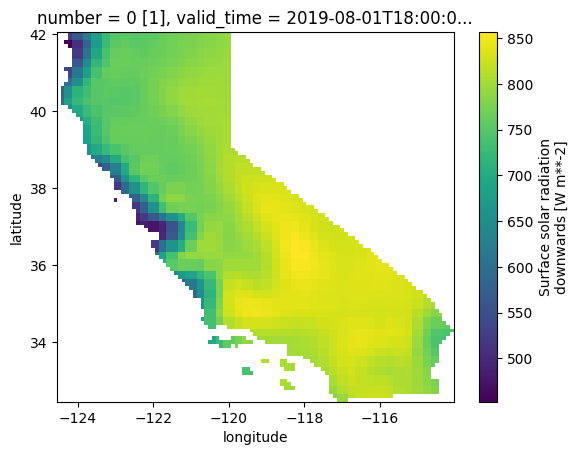

In [20]:
wbgt_inputs_aug_2019["ssrd_W"].where(~mask.isnull()).sel(valid_time="2019-08-01T18:00").plot(cmap="viridis")

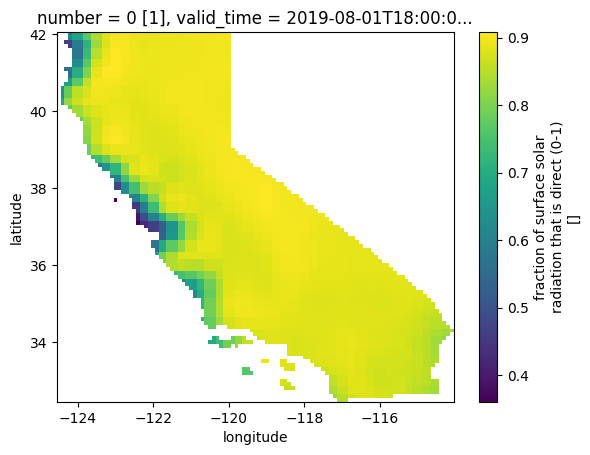

In [21]:
wbgt_inputs_aug_2019["fdir_frac"].where(~mask.isnull()).sel(valid_time="2019-08-01T18:00").plot(cmap="viridis")

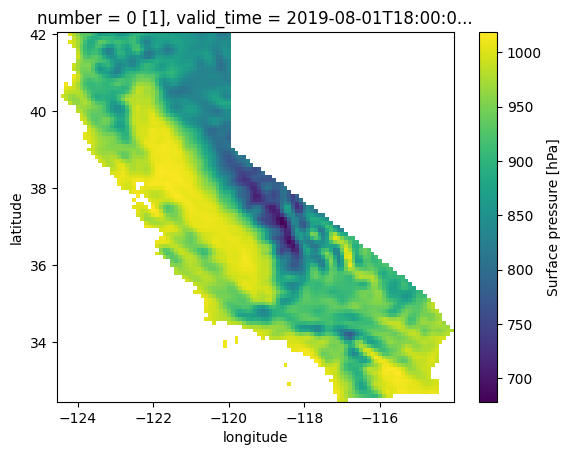

In [22]:
wbgt_inputs_aug_2019["pres"].where(~mask.isnull()).sel(valid_time="2019-08-01T18:00").plot(cmap="viridis")

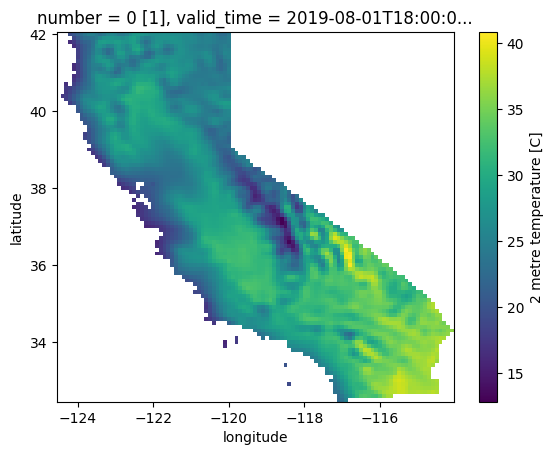

In [23]:
wbgt_inputs_aug_2019["Tair"].where(~mask.isnull()).sel(valid_time="2019-08-01T18:00").plot(cmap="viridis")

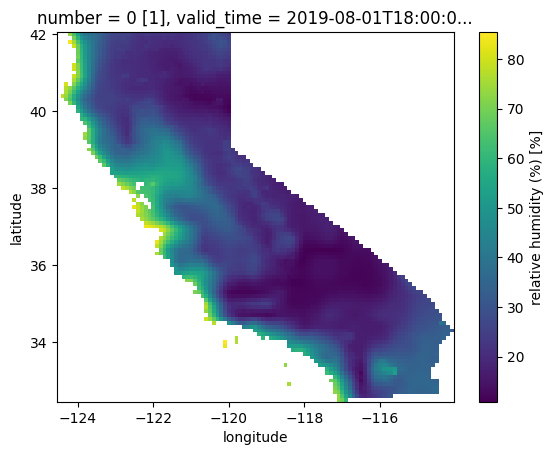

In [24]:
wbgt_inputs_aug_2019["relhum"].where(~mask.isnull()).sel(valid_time="2019-08-01T18:00").plot(cmap="viridis")

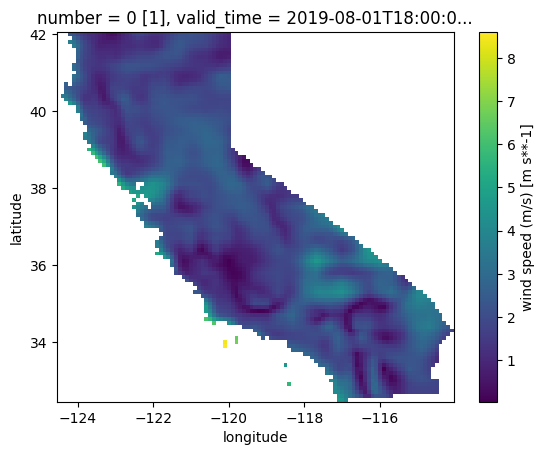

In [25]:
wbgt_inputs_aug_2019["speed"].where(~mask.isnull()).sel(valid_time="2019-08-01T18:00").plot(cmap="viridis")

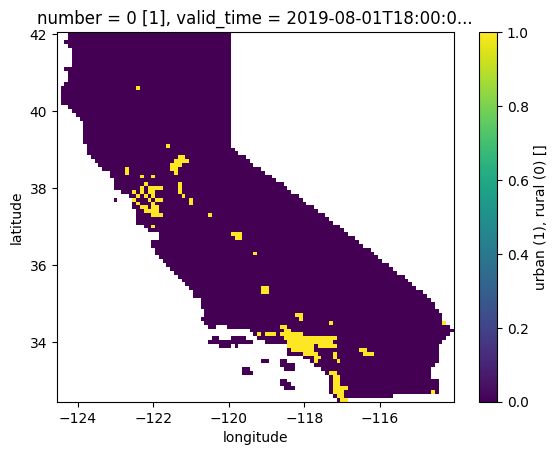

In [26]:
wbgt_inputs_aug_2019["urban"].where(~mask.isnull()).sel(valid_time="2019-08-01T18:00").plot(cmap="viridis")